## Νευρωνικά Δίκτυα - Βαθιά Μάθηση: Εργασία 1
#### Δημήτριος Μουταφτσίδης , 9920 (ΤΗΜΜΥ)
##### moutdimi@ece.auth.gr

Στο Notebook γίνεται αναφορά και σχολιάζεται μόνο το προγραμματιστικό μέρος της εργασίας. Οι έννοιες και τα εργαλεία που αξιοποιούνται εξηγούνται στην συννημένη αναφορά. Το ίδιο ισχύει και για τον σχολιασμό των αποτελεσμάτων. Κάθε Cell αντιστοιχεί σε ένα Markdown Block. Οι λεπτομέρειες συμπληρώνονται από σχόλια. 

In [426]:
import numpy as np

import torch
import torchvision
from torchvision import datasets , transforms , models
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import random as rnd
import time
from pprint import pprint
import os

from sklearn.metrics import confusion_matrix , classification_report

#### 1. Configuration Dictionay.
Επιλέχθηκε σαν τρόπος centralized ελέγχου διαφόρων παραμέτρων εκπαίδευσης. Καλείται από τις περισσότερες συναρτήσεις για να ληφθούν τα αντίστοιχα ορίσματα. Από εδώ ελέγχονται οι παράμετροι που αφορούν το Data Augmentation καθώς και αυτές που αφορούν το ίδιο το νευρωνικό. 

In [429]:
configuration = {

    #Device selection and download path. Adjust accordinglly.
    "device" : "cuda" if torch.cuda.is_available() else "cpu" ,
    "root" :  r"C:\Users\dimit\Desktop\Νευρωνικά\Εργασία 1" ,

    #Batch size and shuffle. These are used by the Data Loaders.
    "batch_size" : 128 ,
    "shuffle" : True ,

#Data Augmentation segment.
    #Random crop parameters that affect the magnitude of the shift.
    "random_crop" : {
        "flag" : True ,
        #Size of final image.
        "size" : 32 ,
        #Added pixels in each direction. Total image is 40x40.
        "padding" : 4 ,
        #Mode -> Reflect uses the border content of the image to fill the padding. Not zeros,
        #ones or any other fixed value.
        "mode" : "reflect" ,
        
    } ,

    #Horizontal flip sub-dictionary.
    "horizontal_flip" : {
        "flag" : True ,
        #Probability that an image is flipped.
        "probability" : 0.5 ,
    } ,

    #Colour Jitter sub-dictionary.
    "jitter" : {
        "flag" : True ,
        #The follwing values scale the corresponding colour aspect of the image in the
        #[1 - value , 1 + value] range.
        "brightness" : 0.15 ,
        "contrast" : 0.15 , 
        "saturation" : 0.15 , 
        "hue" : 0.05 ,
    } , 

    #Random Erasing sub-dictionary.
    "erasing" : {
        "flag" : True , 
        #The specified probability of the erasure.
        "probability" : 0.2 ,
    } ,

#Neuranl Network parameter segment.
    #Width of the Netwok.
    "channels" : [32 , 32 , 32] ,
    #Activation function selection. Only ReLU and Leaky ReLU are supported.
    "activation_function" : "relu" , 
    #Dropout value. Shuts neurons off accordignly.
    "dropout" : 0.2 , 

    #Learning Rate and Weight Decay instruct the Optimizer. Only Adam is used.
    #These values are typical for Adam.
    "learning_rate" : 1e-3 , 
    "weight_decay" : 1e-3 , 
    #Number of epochs.
    "epochs" : 20 , 
    #Scheduler subdictionary.
    "scheduler" : {
        #Only Step and Multistep are supported.
        "type" : "step" , 
        #Number of epochs after which to reduce LR.
        "step_size" : 10 , 
        #Multiplication factor selection after Scheduler activation.
        "gamma" : 0.1 , 
        #Only for Multistep.
        "milestones" : [50 , 100] , 
    } ,

    #Batch Normalization flag.
    "batch_normalization" : True ,
}


#Maximum accuracy achieved: 

#### 2. Λήψη Δεδομένων.
Λήφθηκαν κατευθείαν από την Pytorch χάρην ευκολίας. Το path είναι προσαρμοσμένο στον δικό μου δίσκο. Για την ώρα δεν καλείται κάποιο Transform. Ο διαχωρισμός μεταξύ Training και Test data γίνεται μέσω των αντίστοιχων Flags.

In [432]:
training_set = datasets.CIFAR10(
    root = configuration["root"],
    #Designates data as Training.
    train = True,
    download = True,
    transform = None
)

test_set = datasets.CIFAR10(
    root = configuration["root"],
    #Designates Data as Testing.
    train = False,
    download = True,
    transform = None
)

#### 3. Μέση τιμή και διασπορά.
Μια γρήγορη μετατροπή των εικόνων σε numpy array. Κανονικοποιούμε σε κλίμακα [0,1] πριν τους υπολογισμούς, αφού σε αυτή την κλίματα επεξεργάζονται τα datasets της Troch. Μετατρέπουμε σε tuple για χρήση αργότερα εντός του transforms.Normalize() module. Οι τιμές υπολογίζονται ανά channel. Είναι διανύσματα μήκους 3.

In [434]:
training_images = training_set.data.astype(np.float32) / 255.0

mean = tuple(training_images.mean(axis = (0 , 1 , 2)).tolist())
std = tuple(training_images.std(axis = (0 , 1 , 2)).tolist())

print("Per channel mean : ", mean , "\n")
print("Per channel STD : ", std , "\n")

Per channel mean :  (0.49140089750289917, 0.48215895891189575, 0.4465307891368866) 

Per channel STD :  (0.2470327913761139, 0.243484228849411, 0.261587530374527) 



#### 4. Συνάρτηση Data_Augmentations. 
Εφαρμόζει τις μετατροπές στα δεδομένα. Δέχεται σαν όρισμα το configuration dictionary. Από εκεί εξάγει το ποιές μετατροπές ,και με τι παρμέτρους, θέλουμε να εφαρμόσουμε. Επίσης λαμβάνει σαν όρισμα την μέση τιμή και διασπορά του training set. Πέραν του Augmentation, αναλαμβάνει και την κανονικοποίηση των δεδομένων, καθώς και την μετατροπή τους σε Tensors. Είναι απαραίτητο για να εργαστούμε σε Pytorch. Τέλος, μέσω της μεθόδου Compose(), συνθέτει και επιστρέφει το σύνολο των transforms για κάθε dataset.

##### Μερικά Σχόλια:
1. Η μέθοδος Compose() συνθέτει τις Python List σε callable objects, τα οποία η Torch διαβάζει αυτομάτως.
2. Η Random Erasing τροποποίηση εφαρμόζεται μετά από το Tensor Conversion, αφού περιμένει τέτοιου τύπου αντικείμενα.
3. Για την κανονικοποίηση του test set, χρησιμοποιούμε τις τιμές των training data. Τα πρώτα υποθετικά μας είναι αόρατα. 

In [436]:
def Data_Augmentations(configuration , mean , std):

    #Pre-allocate training transforms as empty list.
    training_transforms = []

    #Extract the random_crop dictionary from configuration.
    crop = configuration["random_crop"]

    #Append said transform if flag is set to True.
    if crop["flag"]:
        training_transforms.append(
            #We use the built-in Pytorch Module RandomCrop.
            #The values are extracted from the crop dictionary.
            transforms.RandomCrop(size = crop["size"] , 
                                 padding = crop["padding"] ,
                                 padding_mode = crop["mode"])
        )

    #Very similar process for Random Horizontal Flip and Colour Jittering.
    #Again, the corresponding sub-dictionaries are extracted and the built-in modules are
    #called.
    flip = configuration["horizontal_flip"]

    if flip["flag"]:
        training_transforms.append(
            transforms.RandomHorizontalFlip(p = flip["probability"])
        )

    jitter = configuration["jitter"]

    if jitter["flag"]:
        training_transforms.append(
            transforms.ColorJitter(brightness = jitter["brightness"] , 
                                  contrast = jitter["contrast"] , 
                                  saturation = jitter["saturation"] ,
                                  hue = jitter["hue"])
        )

    #Append Tensor Conversion and Normalization Transforms as well.
    training_transforms.append(transforms.ToTensor())
    training_transforms.append(transforms.Normalize(mean , std))

    #Extract Random Erasing sub-dict.
    erase = configuration["erasing"]

    #Apply if flag is set to True. Again, using the built-in module.
    if erase["flag"]:
        training_transforms.append(transforms.RandomErasing(p = erase["probability"]))

    #Use Compose to turn list into callable object.
    composed_training_transforms = transforms.Compose(training_transforms)

    #Apply only Tensor Conversion and Normalization to test data.
    testing_transforms = []

    testing_transforms.append(transforms.ToTensor())
    testing_transforms.append(transforms.Normalize(mean , std))

    #Compose second callable object and return.
    composed_testing_transforms = transforms.Compose(testing_transforms)

    return composed_training_transforms , composed_testing_transforms

#### 5. Συνάρτηση Build_dataloaders.
Πολύ απλή συνλαρτηση, κατασκευάστηκε κυρίως για λόγους κομψότητας και συντομίας. Δέχεται σαν όρισμα το configuration και τα datasets. Έπειτα κατασκευάζει και επιστρέφει τα κατάλληλα dataloaders. 
##### Μερικά σχόλια:
1. Τα dataloaders ουσιαστικά "ταϊζουν" τις εικόνες στο Νευρωνικό. Τις ομαδοποιούν σύμφωνα με το batch size για να επιταχύνουν την διαδικασία εκπαίδευσης. Το Loss υπολογίζεται κατά μέσο όρο για όλο το batch.
2. Το shuffle είναι σχεδόν πάντα ενεργό για τα training data και πάντα ανενεργό για τα test data.
3. Παρόλου που μας δίνεται η δυνατότητα για αλλαγή, στα πειράματα πάντα χρησιμοποιήθηκε Batch size = 128 για ισορροπία μεταξύ χρόνου και επίδοσης.

In [439]:
def Build_Dataloaders(configuration , training_set , test_set):
    #Call the buit-in DataLoader method for the traning set.
    training_dataloader = DataLoader(training_set , 
                                     batch_size = configuration["batch_size"] ,
                                    shuffle = configuration["shuffle"])
    #Same process for test set.
    testing_dataloader = DataLoader(test_set , 
                                   batch_size = configuration["batch_size"] , 
                                   shuffle = False)

    return training_dataloader , testing_dataloader

#### 6. Συνάρτηση Activation_Function.
Διαβάζει από το configuration dictionary ποιά activation function θέλουμε και την επιστρέφει. Υποστηρίζει μόνο ReLU και Leaky ReLU για την ώρα.

In [441]:
def Activation_Function(configuration):
    #Get activation function name from configuration. Make it case insensitive.
    name = configuration["activation_function"].lower()

    #Return the appropriate function by calling the built-in modules.
    #Inplace = True is used to overwrite tensors for memory efficiency. Not much significance
    #for our particular applications.
    if name == "relu":
        return nn.ReLU(inplace = True)

    elif name == "leaky_relu":
        return nn.LeakyReLU(0.01 , inplace = True)

    else: 
        raise ValueError("Check configuration. Invalid activation function name.")

#### 7. Συνάρτηση Convolution.
Πολύ σημαντική συνάρτηση. Καθορίζει το feature extraction process πριν την ταξινόμηση. Επιστρέφει ένα List με τις διαδικασίες που πρέπει να εφαρμοστούν στις εικόνες πριν "καταναλωθούν" από το Νευρωνικό. Το Pipeline έχει ως εξής για κάθε Layer πλην του τελευταίου: Συνέλιξη -> Batch Normalization -> Activation Function -> Max Pooling (παραλείπεται στο τελευταίο layer). Έχουμε λοιπόν όσα Convolutional Layers όσο το "πλάτος" του Νευρωνικού. 
##### Παράδειγμα: 
Υποθέτουμε channels = [32 , 64]. Το input έχει 3 κανάλια ως RGB εικόνα.Θα έχουμε δύο συνελικτικά επίπεδα. Στο πρώτο, το δίκτυο θα "μάθει" 32 διαφορετικές 3x3x3 μάσκες. Θα εφαρμόσει Batch Normalization, θα περάσει τα αποτελέσματα από το Activation Function και θα κάνει Max Pooling. Στην συνέχεια, θα "μάθει" 64 32x3x3 μάσκες, με τις οποίες θα συνελίξει τα 32 feature maps που προέκυψαν από πριν και θα προχωρήσει με τα υπόλοιπα (πλην του Max Pooling). Θα δωθούν περισσότερες λεπτομέρειες στην αναφορά.
##### Μερικά Σχόλια:
1. Η συνάρτηση επιστρέφει το pipeline, δεν υλοποιεί εσωτερικά τις διεργασίες. Ουσιαστικά δίνει το "πρόγραμμα" των διεργασιών.
2. Τα kernel sizes,  τόσο της συνέλιξης όσο και του Max Pooling αποτελούν και αυτά "κρυφές" παραμέτρους. Επηρρεάζουν την τελική επίδοση. Ωστόσο, δεν εξερευνούνται περαιτέρω λόγο μεγάλης πολυπλοκότητας.

In [443]:
def Convolution(channels , configuration):

    #Initilize feature layers as empty list.
    feature_layers = []
    #The images are RGB, thus 3 channels.
    input_channels = 3

    #Use of batch normalization eliminates the need for bias.
    if configuration["batch_normalization"]:
        bias = False

    else: 
        bias = True
        
    #Iterate through channels. Keep the index through enumeration.
    for index , output_channels in enumerate(channels):
        #Append the appropriately sized convolution to pipeline. 
        feature_layers.append(
            #Using the built-in 2d convolution module.
            nn.Conv2d(
                #Specify number of input and output channels.
                in_channels = input_channels , 
                out_channels = output_channels , 
                #Standard Kernel size for most applications.
                kernel_size = 3 , 
                padding = 1 , 
                bias = bias
            )
        )
        #Append Batch-Norm to pipeline if requested.
        if configuration["batch_normalization"]:
            feature_layers.append(nn.BatchNorm2d(output_channels))
        #Call Activation_Function function to extract the requested ,well, activation function.
        #Append to pipeline.
        feature_layers.append(Activation_Function(configuration))
        #The number of input channels for the next layer is the current number of output layers.
        #As shown in the example above.
        input_channels = output_channels

        #Apply max pooling to all layers, except for the last.
        if index < min(len(channels) - 1 , 5):
            feature_layers.append(
                #Use built-in module. Standard kernel size for most applications.
                nn.MaxPool2d(kernel_size = 2)
            )
    #Return the pipeline.
    return feature_layers

#### 8. Συνάρτηση Training_Epoch.
Αποτελεί την βασική μονάδα εκπαίδευσης του δικτύου. Εκπαιδεύει για όλα τα mini batches, υλοποιώντας ένα epoch. Δέχεται ως ορίσματα το μοντέλο, το dataloader , τον Optimizer , το κριτήριο επίδοσης και το configuration. Επιστρέφει loss και accuracy για το epoch. Κάθε iteration του for loop "φορτώνει" ένα mini-batch από το data loader. Εκτελεί το Forward Pass και υπολογίζει το loss με βάση το ζητούμενο criterion. Στην συνέχεια προχωρά στο Backward Pass και ενημερώνει τα βάρη μέσω του Optimizer. Υπολογίζει επίσης τα στατιστικά του κάθε batch. Μετά το πέρας του for loop, υπολογίζονται τα per epoch stats.
##### Μερικά Σχόλια:
1. Η εντολή model.train() θέτει το μοντέλο σε φάση εκπαίδευσης. Λειτουργίες όπως το Dropout και το Batch Normalization είναι σε ισχύ.
2. Η PyTorch δεν μηδενίζει τα gradies by default. Η εντολή zero.grad() είναι απαραίτητη για την "ανεξαρτισία" του κάθε mini batch.
3. Το loss υπολογίζεται κατά μέσο όρο για κάθε batch. Για τον υπολογισμό του συνολικού per-epoch loss, πολλαπλασιάζουμε την μέση αυτή τιμή με τον αριθμό των δειγμάτων στο batch.
4. Ο Optimizer καλείται μετά από κάθε batch για την ενημέρωση των βαρών. Επομένως, το μοντέλο "εκπαιδεύεται" και εντός του epoch.
5. Κατά την κλήση της εντολής model(images) , ουσιαστικά ενεργοποιείται το Convolutional Pipeline. Θα δούμε ,στην συνέχεια, το πως το μοντέλο το γνωρίζει ήδη. 

In [446]:
def Training_Epoch(model , dataloader , optimizer , criterion , configuration):

    device = configuration["device"]
    #Set model to training mode. 
    model.train()

    #Initialize counters.
    running_loss = 0.0
    correct = 0
    total = 0

    #Iterate through Data Loader.
    for images , labels in dataloader:
        #Load batch of images and labels.
        images = images.to(device)
        labels = labels.to(device)
        #Reset Gradients. 
        optimizer.zero_grad()
        #Forward pass: work through model pipeline and classify.
        output = model(images)
        #Calculate loss by comparing predictions to actual labels. Almost always Cross Entropy Loss.
        loss = criterion(output , labels)
        #Backwards Pass (Back Propagate): compute gradients with regard to all params. 
        loss.backward()
        #Call optimizer to update weights.
        optimizer.step()

        #Calculate average loss per image and multiply by number of images in batch.
        running_loss += loss.item() * images.size(0)
        #Get predicted class per sample.
        _ , predictions = output.max(1)
        #Calculate number of correct predictions in batch and add to total number of 
        #correct predictions.
        correct += (predictions == labels).sum().item()
        #Add number of current batch samples to number of total samples for this epoch.
        total += labels.size(0)
    #Extract the per-epoch stats.
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss , epoch_accuracy

#### 9. Συνάρτηση Evaluate.
Αναλαμβάνει την αξιολόγηση του μοντέλου. Καλείται από την Train_Model (φαίνεται παρακάτω) για να ενημερώσει για την επίδοση του μοντέλου στο test set. Εκτελεί μόνο το Forward Pass. Δεν καλεί τον Optimizer, οπότε τα βάρη δεν ενημερώνονται ποτέ. Καλέι την model.eval() ,ώστε να απενεργοποιηθούν το dropout και το batch normalization να μπει σε "Testing Mode". Στην συνέχεια εκτελεί μια δομή επανάληψης πολύ παρόμοιας λογικής με αυτήν της Training_Epoch όσον αφορά την εξαγωγή τον στατιστικών. Δεν επεμβαίνει όμως καθόλου στο μοντέλο.
##### Μερικά Σχόλια:
1. Δεν χρειάζεται να χρησιμοποιήσουμε την model.train(). Η Training_Epoch φροντίζει γι' αυτό.
2. Για να είμαι ειληκρινής η model.eval() έλειπε για τα περισσότερα πειράματα. Ξαναέτρεξα κάποια αφού την προσέθεσα χωρίς καμία ουσιαστική διαφορά.
3. Η no_grad() μέθοδος υπαγορεύει στην Torch να σταματήσει να υπολογίζει gradients. Έτσι ο κώδικας γίνεται πιο "ευγενικός" για την μνήμη. 

In [453]:
def Evaluate(model , dataloader , criterion , configuration):

    device = configuration["device"]
    #Switch to evaluation mode.
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    #Use no_grad() to relieve memory from gradient storing.
    with torch.no_grad():
        #Iterate through dataloader for all mini batches.
        for images , labels in dataloader:
            #Load samples and labels.
            images = images.to(device)
            labels = labels.to(device)
            #Predict.
            outputs = model(images)
            #calculate loss.
            loss = criterion(outputs , labels)
            #Extract statistic like before.
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    #Calculate across-epoch statistics.
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss , epoch_accuracy

#### 10. Συνάρτηση Scheduler.
Dead code basically. Εκτελεί το βήμα του scheduler. Δεν επιστρέφει κάτι. Υποτείθεται θα χειριζόταν διάφορα schedulers αλλά κατέληξε να επικαλείπτεται σχεδόν πλήρως από την Build_Scheduler που ακολουθεί. Απλώς ενημερώνει τον Optimizer να μειώσει το learning rate σε συγκεκριμένο epoch.

In [456]:
def Scheduler(scheduler , configuration):
    #Redundant.
    if scheduler is None:
        return
    #Redundant.
    scheduler_config = configuration.get("scheduler" , {})
    scheduler_type = scheduler_config.get("type" , "none").lower()
    #Instruct Scheduler to take a step.
    scheduler.step()

#### 11. Συνάρτηση Train_Model.
Συνολική συνάρτηση εκπαίδευσης μοντέλου για τα ζητούμενα epochs. Καλεί τις Train_Epoch και Evaluate για την εκπαίδευση και per epoch αξιολόγηση του Δικτύου αντίστοιχα. Επιστρέφει το performance dictionary και το best_state. Το πρώτο περιέχει τα statistics της εκπαίδευσης ανά epoch. Χρήσιμο για τον υπολογισμό του training curve. Το δεύτερο είναι dictionary που περιέχει τα βάρη που πέτυχαν την καλύτερη επίδοση. Επειδή αξιολογούμε με βάση τα test data, τα οποία δεν εμπλέκονται καθόλου στο training, είμαστε πιο σίγουροι για τα αποτελέσματα. Εντός του loop, καλέι διαδοχικά την Train_epoch και Evaluate. Καλεί επίσης τον Scheduler. Τέλος, ενημερώνει τα στατιστικά και εκτυπώνει τα τωρινά αποτελέσματα για το εκάστοτε epoch.
##### Μερικά Σχόλια.
1. Δεν υπάρχει κάποιο train-test split, αφού η CIFAR-10 προσφέρει ξεχωριστό σετ για την κάθε διεργασία. Στην πράξη, το test set λειτουργεί σαν Validation Set.
2. Το dictionary με τα βάρη μπορεί να αποθηκευτεί στον δίσκο ώστε το μοντέλο να εξάγεται αυτούσιο χωρίς επανεκπαίδευση.

In [459]:
def Train_Model(model , training_dataloader , test_dataloader , configuration , optimizer , scheduler = None , criterion = None):

    device = configuration["device"]
    
    #Cross Entropy Loss is selected unless told other wise.
    #The function handle for criterion defaults to None.
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    
    #Get number of epochs from configuration.
    epochs = configuration["epochs"]
    
    #Create dictionary of empty lists to store losses and acurracies.
    performance = {
        "training_loss" : [] , 
        "training_accuracy" : [] , 
        "testing_loss" : [] , 
        "testing_accuracy" : []
    }
    
    best_accuracy = 0.0
    best_state = None
    
    #Get start time.
    start = time.time()
    
    #Train for number of required epochs.
    for epoch in range(epochs):
        
        #Get training loss and accuracy by calling Training_Epoch.
        #This also trains the model, as we saw earlier.
        training_loss , training_accuracy = Training_Epoch(model , training_dataloader , optimizer , criterion , configuration)
        
        #Evaluate model. No changes are done at all in this step.
        testing_loss , testing_accuracy = Evaluate(model , test_dataloader , criterion , configuration)
        
        #Call scheduler in case it needs to step in. Would be the same to just
        #call scheduler.step() but anyway.
        Scheduler(scheduler , configuration)
        
        #Append metrics to corresponding category.
        performance["training_loss"].append(training_loss)
        performance["training_accuracy"].append(training_accuracy)
        performance["testing_loss"].append(testing_loss)
        performance["testing_accuracy"].append(testing_accuracy)

        #Check for improved accuracy. If so, update best_state.
        #Again, we judge based on performance on test data.
        if testing_accuracy > best_accuracy:
            best_accuracy = testing_accuracy
            best_state = model.state_dict()

        #Print epoch results.
        print(  f"Epoch [{epoch+1} / {epochs}]"
                f"Training Loss: {training_loss: .4f} | Training Accuracy: {training_accuracy * 100 : .2f}%"
                f"Test Loss {testing_loss: .4f} | Test Accuracy: {testing_accuracy * 100 : .2f}%")
    #Calculate total training time.
    total_time = time.time() - start

    #Print training time and best achieved accuracy.
    print(f"\nBest accuracy: {best_accuracy * 100 : .2f}%")
    print(f"Total Training Time: {total_time / 60: .1f} minutes.")

    #Return history and state.
    return performance , best_state

#### 12. Συνάρτηση Build_Adam.
Δημιουργεί και επιστρέφει τον Optimizer, διαβάζοντας τις παραμέτρους (learning rate & weight decay) από το configuration. Η λειτουργία του θα αναλυθεί περισσότερο στο report.
##### Μερικά σχόλια:
1. Ο Optimizer επικοινωνεί αυτόματα με το μοντέλο. Αρκεί η κλίση του .step(). Δεν χρειάζεται περεταίρω tweaks.

In [462]:
def Build_Adam(configuration , model):
    #Call optim.Adam to create optimizer object.
    optimizer = optim.Adam(model.parameters() , 
                          lr = configuration["learning_rate"] , 
                          weight_decay = configuration["weight_decay"]
                          )

    return optimizer

#### 13. Συνάρτηση Build_Scheduler.
Δημιουργεί και επιστρέφει τον Scheduler. Διαβάζει το configuration και ανάλογα με τον τύπο και τις παραμέτρους που ζητούνται καλεί την κατάλληλη μέθοδο. Χειρίζεται μόνο Step και MultiStep Schedulers. Μπορεί να δεχτεί και None.

In [465]:
def Build_Scheduler(configuration , optimizer):

    #Get scheduler configuration sub-dictionary.
    scheduler_configuration = configuration.get("scheduler" , None)

    #If None, return None.
    if scheduler_configuration is None:
        return None

    #Get type.
    scheduler_type = scheduler_configuration.get("type" , "none").lower()

    #If type is set to "none", return None.
    if scheduler_type == "none":
        return None

    #Create Step Scheduler object through the built-in PyTorch method.
    if scheduler_type == "step":
        scheduler = optim.lr_scheduler.StepLR(
            optimizer , 
            step_size = scheduler_configuration["step_size"] , 
            gamma = scheduler_configuration["gamma"]
        )
        return scheduler

    #Create MultiStep Scheduler object through the Built-In Pytorch method.
    if scheduler_type == "multistep":
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer , 
            milestones = scheduler_configuration["milestones"] ,
            gamma = scheduler_configuration["gamma"]
        )
        return scheduler

    #Else, raise a Value Error to indicate incorrect selection.
    raise ValueError("Invalid Scheduler Type. Check configuration.")

#### 14. Συνάρτηση Training_Curve.
Βοηθητική συνάρτηση. Σχεδιάζει το training curve με βάση τα statistics του performance dictionary.

In [468]:
def Training_Curve(performance):

    epochs = range(1 , len(performance["training_loss"]) + 1)

    #Plot Loss curves for training and Testing.
    plt.figure()
    plt.plot(epochs , performance["training_loss"] , label = "Training Loss")
    plt.plot(epochs , performance["testing_loss"], label = "Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    #Plot Accuracy curves for training and testing.
    plt.figure()
    plt.plot(epochs , performance["training_accuracy"] , label = "Training Accuracy")
    plt.plot(epochs , performance["testing_accuracy"] , label = "Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

#### 15. Συνάρτηση Predictions.
Τρέχει το εκπαιδευμένο μοντέλο πάνω στα δεδομένα του δωσμένου data loader. Επιστρέφει τις προβλεπόμενα και τα πραγματικά labels στην μορφή numpy arrays. 
##### Μερικά Σχόλια:
1. Πριν το τελικό concatenation, τα labels και ατ predictions στην ουσία είναι arrays διανυσμάτων. Ένα διάνυσμα για κάθε batch.

In [471]:
def Predictions(model , dataloader , configuration):

    device = configuration["device"]
    #Switch on evaluation mode.
    model.eval()

    #Preallocate labels and predictions.
    labels = []
    predictions = []

    #Use no_grad() for efficiency.
    with torch.no_grad():

        #Similar loop as shown in Evaluate().
        for image , label in dataloader:
            image = image.to(device)
            #Get predictions.
            output = model(image)
            _ , prediction = output.max(1)

            #Append batch labels and predictions to corresponding lists.
            labels.append(label.numpy())
            predictions.append(prediction.cpu().numpy())
    
    #Merge all batches to single arrays.
    true_labels = np.concatenate(labels)
    predicted_labels = np.concatenate(predictions)

    return true_labels , predicted_labels

#### 16. Συνάρτηση Model_Statistics.
Καλεί τις μεθόδους της sklearn για υπολογισμό του confusion matrix και του classification report. Εκτυπώενι και τα δύο, χωρίς να τα επιστρέφει. Πολύ παρόμοια αρχιτεκτονική είχαι χρησιμοποιηθεί στην ενδιάμεση εργασία.

In [474]:
def Model_Statistics(model , dataloader , configuration ,  print_report = True):

    #Get class names as to not show just the label numbers.
    class_names = dataloader.dataset.classes

    #Call Predictions to get true and predicted labels.
    true_labels , predicted_labels = Predictions(model , dataloader , configuration)

    #Use SickitLearn's built-in module to create the Confusion Matrix.
    cm = confusion_matrix(true_labels , predicted_labels)

    #Create the classification report by passing the results and the class names. 
    #Store it as dictionary.
    report = classification_report(
        true_labels , 
        predicted_labels ,
        target_names = class_names ,
        output_dict = True
    )

    overall_accuracy = report["accuracy"]

    #Print the results.
    print(f"\n Overall accuracy: {overall_accuracy * 100: .2f}% \n")
    print("Classification Report: \n")
    print(classification_report(true_labels , 
                                predicted_labels ,
                                target_names = class_names ,
                                output_dict = False))

    #Print the confusion matrix.
    Plot_CM(cm , class_names)
    

#### 17. Συνάρτηση Plot_CM.
Απλώς εκτυπώνει το confusion matrix με ωραίο τρόπο. Nothing more to see here.

In [477]:
def Plot_CM(cm , class_names):

    fmt = "d"
    
    plt.figure(figsize = (8 , 8))
    plt.imshow(cm , interpolation = "nearest" , cmap = "Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks , class_names , rotation = 45)
    plt.yticks(tick_marks , class_names)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            plt.text(
                j, i,
                format(value, fmt),
                ha="center", va="center",
                color="white" if value > thresh else "black"
            )
    
    
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

#### 18. Μοντέλο CNN: Kasper.
Ορίζεται σαν κλάση που κληρονομεί από την nn.Module. Πρόκειται για την βάση όλων των μοντέλων της PyTorch. Ο παρακάτω ορισμός ουσιαστικά αποτελεί wrapper για την συνολικη αρχιτεκτονική του μοντέλου. Οι περισσότεροι παράμετροι ελέγχονται από το configuration dictionary. Το μόνο που είναι hard wired είναι ο αριθμός των Hidden Layers. Είναι και αυτό παράμετρος που αξίζει διερεύνηση, ωστόσο έτσι συγχέεται η έννοια του κατά πόσο το μοντέλο είναι το "ίδιο". Δεν θα εξεταστεί στα πλαίσια αυτής της εργασίας. 
##### Μερικά Σχόλια: 
1. Το trick με το dummy input μας επιτρέπει να τροποποιούμε την αρχιτεκτονική της Convolution() χωρίς περεταταίρω αλλαγές.
2. Η κλίση της nn.Sequencial() επιτρέπει ουσιαστικά στην Torch να διατρέχει εσωτερικά το pipeline χωρίς να χρειαστεί να γράψουμε κάποιο loop.

In [484]:
class Kasper(nn.Module):

    #Define the constructor. Allows for Kasper object creation. Reads the configuration dictionary.
    def __init__ (self , configuration , classes = 10):

        #Call the parent for Torch to take over.
        super().__init__()

        #Store the configuration inside of the class for easier access.
        self.configuration = configuration

        #Extract filters/layers and dropout to handle locally.
        channels = configuration["channels"]
        dropout = configuration["dropout"]

        #Get working pipeline from Convolution function.
        feature_layers = Convolution(channels , configuration)

        #Unpack pipeline list and call Sequential to iterate through it.
        self.features = nn.Sequential(*feature_layers)

        #Create dummy input. Necessary in order to determine the number of output features,
        #with no further manuall calculation.
        blank = torch.zeros(2 , 3 , 32 , 32)
        
        #We talked about what no_grad() does. For the dummy run we wish to discard the 
        #gradients.
        with torch.no_grad():
            #Extract the dummy feature population by running a forward pass.
            blank_out = self.features(blank)

        #Calculate length of feature vector after flattening.
        flat_dimension = blank_out[0].numel()

        #Set size of hidden fully connected layer. Default choice for a medium sized model.
        hidden_dimension = 128

        #Call classifier head.
        self.classifier = nn.Sequential(
            #Get the flattened Convolution() output. 
            nn.Flatten() ,
            #Map to hidden units.
            nn.Linear(flat_dimension , hidden_dimension) , 
            #Pass through activation function.
            Activation_Function(configuration) , 
            #Shut neurona off according to dropout.
            nn.Dropout(dropout) , 
            #Map hidden dimension to output classes.
            nn.Linear(hidden_dimension , classes)
        )

    #Define workflow. Extract features, then classify.
    def forward(self , x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [419]:
training_transform , test_transform = Data_Augmentations(configuration , mean , std)

training_set.transform = training_transform
test_set.transform = test_transform

training_dataloader , test_dataloader = Build_Dataloaders(configuration , training_set , test_set)

model = Kasper(configuration).to(configuration["device"])

optimizer = Build_Adam(configuration , model)
scheduler = Build_Scheduler(configuration , optimizer)

performance , best_state = Train_Model(
    model,
    training_dataloader,
    test_dataloader,
    configuration,
    optimizer,
    scheduler = scheduler
)

torch.save(performance , "kasper_performance_128.pth")
torch.save(best_state , "kasper_best_128.pth")

Epoch [1 / 20]Training Loss:  1.4851 | Training Accuracy:  45.89%Test Loss  1.1629 | Test Accuracy:  58.42%
Epoch [2 / 20]Training Loss:  1.2101 | Training Accuracy:  56.63%Test Loss  0.9650 | Test Accuracy:  66.22%
Epoch [3 / 20]Training Loss:  1.0925 | Training Accuracy:  60.88%Test Loss  0.9847 | Test Accuracy:  64.45%
Epoch [4 / 20]Training Loss:  1.0299 | Training Accuracy:  63.32%Test Loss  0.8736 | Test Accuracy:  69.85%
Epoch [5 / 20]Training Loss:  0.9867 | Training Accuracy:  65.00%Test Loss  0.7935 | Test Accuracy:  71.65%
Epoch [6 / 20]Training Loss:  0.9602 | Training Accuracy:  66.06%Test Loss  0.7835 | Test Accuracy:  72.03%
Epoch [7 / 20]Training Loss:  0.9312 | Training Accuracy:  67.12%Test Loss  0.7801 | Test Accuracy:  72.89%
Epoch [8 / 20]Training Loss:  0.9151 | Training Accuracy:  67.78%Test Loss  0.7714 | Test Accuracy:  72.95%
Epoch [9 / 20]Training Loss:  0.8970 | Training Accuracy:  68.36%Test Loss  0.7856 | Test Accuracy:  73.29%
Epoch [10 / 20]Training Loss


 Overall accuracy:  79.59% 

Classification Report: 

              precision    recall  f1-score   support

    airplane       0.80      0.83      0.81      1000
  automobile       0.87      0.92      0.89      1000
        bird       0.75      0.65      0.70      1000
         cat       0.65      0.59      0.62      1000
        deer       0.77      0.78      0.78      1000
         dog       0.70      0.72      0.71      1000
        frog       0.81      0.88      0.84      1000
       horse       0.82      0.84      0.83      1000
        ship       0.88      0.89      0.89      1000
       truck       0.87      0.87      0.87      1000

    accuracy                           0.80     10000
   macro avg       0.79      0.80      0.79     10000
weighted avg       0.79      0.80      0.79     10000



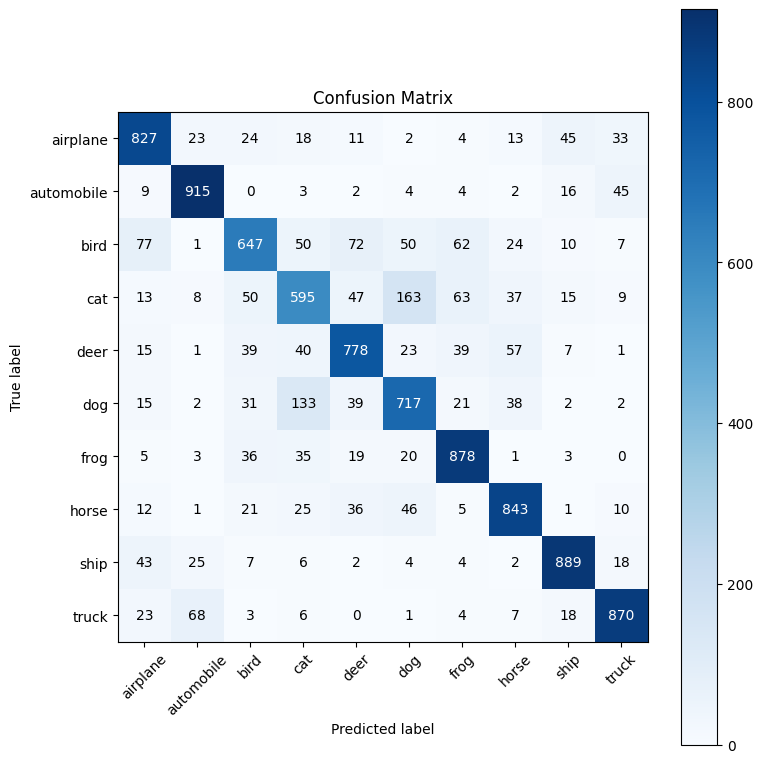

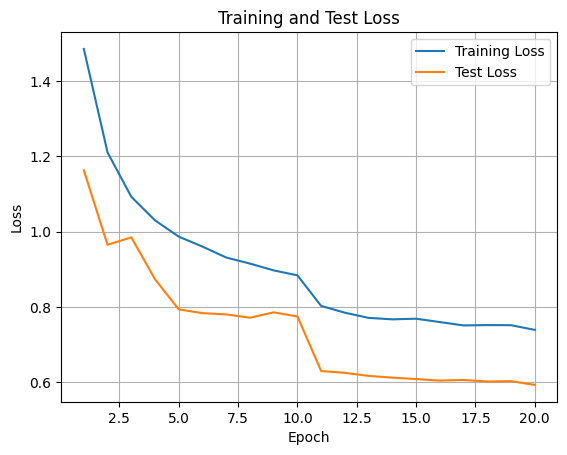

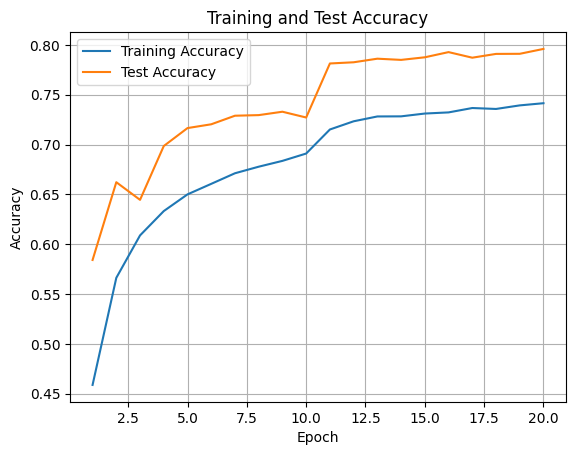

In [486]:
_ , test_transform = Data_Augmentations(configuration , mean , std)
test_set.transform = test_transform

_ , test_dataloader = Build_Dataloaders(configuration , training_set , test_set)

device = configuration["device"]

model_1 = Kasper(configuration).to(device)

state = torch.load(r"C:\Users\dimit\kasper_best_128.pth" , map_location = device)
performance = torch.load(r"C:\Users\dimit\kasper_performance_128.pth" , map_location = device)
model_1.load_state_dict(state)
model_1.eval()

Model_Statistics(model_1 , test_dataloader , configuration)
Training_Curve(performance)